In [324]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Attention
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split



In [325]:
#import data from /Users/jaytlinaskew/GitRepository/TimeSeries-Analysis/data/processed/ProcessedObservedData.csv
data = pd.read_csv(r'C:\Users\jaskew\Documents\project_repository\notebooks\observationEventForecasting\DataPreprocessing\FullIndicatorMatrix.csv')
data.drop(columns=['API_UserName','observations','day','month'], inplace=True)
# Ensure the 'date' column is in datetime format
data['date'] = pd.to_datetime(data['date'])
#data = data[data['indicator'] == '46.246.8.21']
data.tail(10)

,date,indicator,dayofweek,is_weekend,seen
66660,2025-04-28,169.150.196.3,0,False,0
66661,2025-04-28,cssp.org,0,False,0
66662,2025-04-28,103.216.220.19,0,False,0
66663,2025-04-28,111.90.150.140,0,False,1
66664,2025-04-28,169.150.223.208,0,False,1
66665,2025-04-28,194.180.49.217,0,False,1
66666,2025-04-28,199.58.185.9,0,False,0
66667,2025-04-28,45.84.107.128,0,False,1
66668,2025-04-28,138.199.15.147,0,False,0
66669,2025-04-28,104.192.3.74,0,False,1


In [326]:
# Utility function for smoothing values
def smooth(values, weight=0.8):
    smoothed = []
    last = values[0]
    for v in values:
        last = last * weight + (1 - weight) * v
        smoothed.append(last)
    return smoothed

# Example usage:
# modelData['smoothed_days_since_last_seen'] = smooth(modelData['days_since_last_seen'].values, weight=0.8)

In [327]:
# Ensure the data is sorted by 'indicator' and 'date'
data = data.sort_values(['indicator', 'date']).reset_index(drop=True)

# Initialize the 'days_since_last_seen' column with default values
data['days_since_last_seen'] = np.nan

# Calculate days since 'seen' was last equal to 1 for each indicator
for indicator, group in data.groupby('indicator'):
    # Filter rows where 'seen' is 1
    seen_dates = group[group['seen'] == 1]['date']
    
    # Calculate the difference in days for each row
    group['days_since_last_seen'] = group['date'].apply(
        lambda x: (x - seen_dates[seen_dates < x].max()).days if not seen_dates[seen_dates < x].empty else np.nan
    )
    
    # Update the main DataFrame
    data.loc[group.index, 'days_since_last_seen'] = group['days_since_last_seen']

# Fill NaN values with 0 (e.g., for the first occurrence of each indicator)
data['days_since_last_seen'] = data['days_since_last_seen'].fillna(0).astype(int)

# Add exponentially weighted mean of past activity (ewm_seen)
data['ewm_seen'] = data.groupby('indicator')['seen'].apply(lambda x: x.ewm(span=3, adjust=False).mean()).reset_index(drop=True)

# Add rolling count of 'seen == 1' in the last 3 days (seen_count_last_3)
data['seen_count_last_3'] = data.groupby('indicator')['seen'].apply(lambda x: x.rolling(window=3, min_periods=1).sum()).reset_index(drop=True)

# Add rolling averages for 'seen' over different windows
rolling_windows = [7, 14, 30]
for window in rolling_windows:
    data[f'rolling_mean_{window}'] = data.groupby('indicator')['seen'].transform(lambda x: x.rolling(window=window, min_periods=1).mean())

# Add longer exponential moving averages
data['ewm_seen_long'] = data.groupby('indicator')['seen'].transform(lambda x: x.ewm(span=10, adjust=False).mean())

# Total seen over time
total_seen = data.groupby('indicator')['seen'].transform('sum')

# Add total seen in the last 30, 14, 7, and 3 days
time_windows = [30, 14, 7, 3]
for window in time_windows:
    data[f'total_seen_last_{window}'] = data.groupby('indicator')['seen'].transform(lambda x: x.rolling(window=window, min_periods=1).sum())

# Add total days not seen in the last 30, 14, and 7 days
for window in [30, 14, 7]:
    data[f'total_days_not_seen_last_{window}'] = data.groupby('indicator')['seen'].transform(lambda x: window - x.rolling(window=window, min_periods=1).sum())

# Use total_seen for activity_score
data['activity_score'] = total_seen

# Normalize activity_score
data['activity_score_normalized'] = (data['activity_score'] - data['activity_score'].min()) / (
    data['activity_score'].max() - data['activity_score'].min()
)

# Categorize into tiers
data['activity_tier'] = pd.qcut(total_seen, q=3, labels=[0, 1, 2])  # 0 = low, 1 = medium, 2 = high

# Smooth the 'days_since_last_seen' column
data['smoothed_days_since_last_seen'] = smooth(data['days_since_last_seen'].values, weight=0.8)

In [328]:
data['date'] = pd.to_datetime(data['date'])
test_data = data[data['date'] == '2025-04-28 00:00:00']
#cutoff data 7 days ago and on
cutoff_date = datetime.now() - timedelta(days=7)
modelData = data[data['date'] <= cutoff_date]
modelData = modelData.sort_values(['indicator', 'date']).reset_index(drop=True)

In [329]:
modelData[modelData['indicator'] == '102.129.153.43']

,date,indicator,dayofweek,is_weekend,seen,days_since_last_seen,ewm_seen,seen_count_last_3,rolling_mean_7,rolling_mean_14,...,total_seen_last_14,total_seen_last_7,total_seen_last_3,total_days_not_seen_last_30,total_days_not_seen_last_14,total_days_not_seen_last_7,activity_score,activity_score_normalized,activity_tier,smoothed_days_since_last_seen


In [330]:
test_data

,date,indicator,dayofweek,is_weekend,seen,days_since_last_seen,ewm_seen,seen_count_last_3,rolling_mean_7,rolling_mean_14,...,total_seen_last_14,total_seen_last_7,total_seen_last_3,total_days_not_seen_last_30,total_days_not_seen_last_14,total_days_not_seen_last_7,activity_score,activity_score_normalized,activity_tier,smoothed_days_since_last_seen
117,2025-04-28,102.165.16.161,0,False,0,22,1.192093e-07,0.0,0.000000,0.000000,...,0.0,0.0,0.0,29.0,14.0,7.0,1,0.000000,0,18.029515
235,2025-04-28,102.68.39.251,0,False,0,35,2.820677e-11,0.0,0.000000,0.000000,...,0.0,0.0,0.0,30.0,14.0,7.0,8,0.059829,1,31.002512
353,2025-04-28,103.140.63.154,0,False,1,1,9.990196e-01,3.0,1.000000,0.928571,...,13.0,7.0,3.0,13.0,1.0,0.0,17,0.136752,2,1.011036
471,2025-04-28,103.149.249.226,0,False,0,33,5.820766e-11,0.0,0.000000,0.000000,...,0.0,0.0,0.0,30.0,14.0,7.0,1,0.000000,0,29.002535
589,2025-04-28,103.216.220.19,0,False,0,4,3.125000e-02,0.0,0.142857,0.071429,...,1.0,1.0,0.0,29.0,13.0,6.0,1,0.000000,0,1.638400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66197,2025-04-28,www.powerlineblog.com,0,False,0,9,1.220718e-03,0.0,0.000000,0.142857,...,2.0,0.0,0.0,27.0,12.0,7.0,16,0.128205,2,6.506067
66315,2025-04-28,www.sthda.com,0,False,0,5,2.359009e-02,0.0,0.285714,0.214286,...,3.0,2.0,0.0,25.0,11.0,5.0,22,0.179487,2,3.668056
66433,2025-04-28,www.thetruthaboutguns.com,0,False,0,6,7.812500e-03,0.0,0.142857,0.071429,...,1.0,1.0,0.0,29.0,13.0,6.0,1,0.000000,0,3.048576
66551,2025-04-28,www.totem.tech,0,False,0,27,3.725305e-09,0.0,0.000000,0.000000,...,0.0,0.0,0.0,29.0,14.0,7.0,2,0.008547,0,23.043696


In [331]:
# Generate sequences with 15 lags, including only important features
sequences = []
window = 2

for indicator, group in modelData.groupby("indicator"):
    group = group.sort_values("date").reset_index(drop=True)
    for i in range(len(group) - window):
        # Ensure the required columns exist in the group DataFrame
        required_columns = [
            'smoothed_days_since_last_seen', 
            'activity_score_normalized', 
            'activity_score', 
            'ewm_seen_long', 
            'ewm_seen', 
            'rolling_mean_30'
        ]
        
        # Add lagged columns dynamically if they are missing
        for col in required_columns:
            for lag in range(1, window + 1):
                lagged_col = f'lag_{lag}_{col}'
                if lagged_col not in group.columns:
                    group[lagged_col] = group[col].shift(lag)

        seq = group.iloc[i:i+window][[
            'smoothed_days_since_last_seen', 
            'activity_score_normalized', 
            'activity_score', 
            'lag_1_ewm_seen_long', 
            'lag_2_ewm_seen_long', 
            'lag_1_ewm_seen', 
            'lag_2_ewm_seen', 
            'lag_1_rolling_mean_30', 
            'lag_2_rolling_mean_30'
        ]].values
        label = group['seen'].iloc[i+window]
        date = group['date'].iloc[i+window]  # Get the date corresponding to the label

        # Directly reference precomputed features
        activity_score = group['activity_score'].iloc[0]
        activity_score_normalized = group['activity_score_normalized'].iloc[0]
        smoothed_days_since_last_seen = group['smoothed_days_since_last_seen'].iloc[0]

        sequences.append({
            'date': date,  # Add the date here
            'label': label,
            'indicator': indicator,
            'activity_score': activity_score,
            'activity_score_normalized': activity_score_normalized,
            'smoothed_days_since_last_seen': smoothed_days_since_last_seen,
            **{f'lag_{j+1}_smoothed_days_since_last_seen': val[0] for j, val in enumerate(seq)},
            **{f'lag_{j+1}_activity_score_normalized': val[1] for j, val in enumerate(seq)},
            **{f'lag_{j+1}_activity_score': val[2] for j, val in enumerate(seq)},
            **{f'lag_{j+1}_ewm_seen_long_1': val[3] for j, val in enumerate(seq)},
            **{f'lag_{j+1}_ewm_seen_long_2': val[4] for j, val in enumerate(seq)},
            **{f'lag_{j+1}_ewm_seen_1': val[5] for j, val in enumerate(seq)},
            **{f'lag_{j+1}_ewm_seen_2': val[6] for j, val in enumerate(seq)},
            **{f'lag_{j+1}_rolling_mean_30_1': val[7] for j, val in enumerate(seq)},
            **{f'lag_{j+1}_rolling_mean_30_2': val[8] for j, val in enumerate(seq)}
        })

# Convert sequences to a DataFrame
sequence_df = pd.DataFrame(sequences)

# Save the DataFrame to a CSV file
sequence_df.to_csv(r"C:\Users\jaskew\Documents\project_repository\data\sequence_data_for_lstm.csv", index=False)

In [332]:
sequence_df.head(500)

,date,label,indicator,activity_score,activity_score_normalized,smoothed_days_since_last_seen,lag_1_smoothed_days_since_last_seen,lag_2_smoothed_days_since_last_seen,lag_1_activity_score_normalized,lag_2_activity_score_normalized,...,lag_1_ewm_seen_long_2,lag_2_ewm_seen_long_2,lag_1_ewm_seen_1,lag_2_ewm_seen_1,lag_1_ewm_seen_2,lag_2_ewm_seen_2,lag_1_rolling_mean_30_1,lag_2_rolling_mean_30_1,lag_1_rolling_mean_30_2,lag_2_rolling_mean_30_2
0,2025-01-03,0,102.165.16.161,1,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN
1,2025-01-04,0,102.165.16.161,1,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,NaN,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0
2,2025-01-05,0,102.165.16.161,1,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2025-01-06,0,102.165.16.161,1,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2025-01-07,0,102.165.16.161,1,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,2025-03-03,0,103.216.220.19,1,0.0,23.202028,0.000044,0.000036,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
496,2025-03-04,0,103.216.220.19,1,0.0,23.202028,0.000036,0.000028,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
497,2025-03-05,0,103.216.220.19,1,0.0,23.202028,0.000028,0.000023,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
498,2025-03-06,0,103.216.220.19,1,0.0,23.202028,0.000023,0.000018,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [333]:
modelData[modelData['indicator'] == '192.124.249.112']

,date,indicator,dayofweek,is_weekend,seen,days_since_last_seen,ewm_seen,seen_count_last_3,rolling_mean_7,rolling_mean_14,...,total_seen_last_14,total_seen_last_7,total_seen_last_3,total_days_not_seen_last_30,total_days_not_seen_last_14,total_days_not_seen_last_7,activity_score,activity_score_normalized,activity_tier,smoothed_days_since_last_seen
26307,2025-01-01,192.124.249.112,2,False,0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,30.0,14.0,7.0,2,0.008547,0,2.556301e+00
26308,2025-01-02,192.124.249.112,3,False,0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,30.0,14.0,7.0,2,0.008547,0,2.045041e+00
26309,2025-01-03,192.124.249.112,4,False,0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,30.0,14.0,7.0,2,0.008547,0,1.636033e+00
26310,2025-01-04,192.124.249.112,5,True,0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,30.0,14.0,7.0,2,0.008547,0,1.308826e+00
26311,2025-01-05,192.124.249.112,6,True,0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,30.0,14.0,7.0,2,0.008547,0,1.047061e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26413,2025-04-17,192.124.249.112,3,False,0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,30.0,14.0,7.0,2,0.008547,0,1.365057e-10
26414,2025-04-18,192.124.249.112,4,False,0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,30.0,14.0,7.0,2,0.008547,0,1.092045e-10
26415,2025-04-19,192.124.249.112,5,True,0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,30.0,14.0,7.0,2,0.008547,0,8.736362e-11
26416,2025-04-20,192.124.249.112,6,True,0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,30.0,14.0,7.0,2,0.008547,0,6.989090e-11


In [334]:
# Check data types
print(modelData.dtypes)

# Convert 'seen' column to numeric if necessary
modelData['seen'] = pd.to_numeric(modelData['seen'], errors='coerce')

# Ensure 'date' column is in datetime format
modelData['date'] = pd.to_datetime(modelData['date'], errors='coerce')

date                             datetime64[ns]
indicator                                object
dayofweek                                 int64
is_weekend                                 bool
seen                                      int64
days_since_last_seen                      int64
ewm_seen                                float64
seen_count_last_3                       float64
rolling_mean_7                          float64
rolling_mean_14                         float64
rolling_mean_30                         float64
ewm_seen_long                           float64
total_seen_last_30                      float64
total_seen_last_14                      float64
total_seen_last_7                       float64
total_seen_last_3                       float64
total_days_not_seen_last_30             float64
total_days_not_seen_last_14             float64
total_days_not_seen_last_7              float64
activity_score                            int64
activity_score_normalized               

In [371]:
# Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, roc_auc_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

# --- Load and Preprocess Data ---
# Load processed data
df = pd.read_csv(r"C:\Users\jaskew\Documents\project_repository\data\sequence_data_for_lstm.csv")

# Separate features and labels
X = df.drop(columns=['label', 'indicator'])
y = df['label'].values
indicators = df['indicator'].values  # If needed

# Clean feature columns
X.columns = X.columns.str.strip()

# Coerce all data to numeric, fill missing, cast to float32
X = X.apply(pd.to_numeric, errors='coerce').fillna(0).astype(np.float32)

# Standardize features (important for LSTM/NNs)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape for LSTM: (samples, timesteps, features)
X_scaled = X_scaled.reshape((X_scaled.shape[0], X_scaled.shape[1], 1))

# Train/test split
X_train, X_test, y_train, y_test, ind_train, ind_test = train_test_split(
    X_scaled, y, indicators, test_size=0.2, random_state=42
)

# --- Define Focal Loss ---
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        return tf.reduce_mean(alpha * tf.pow((1 - p_t), gamma) * bce)
    return loss

# --- Compute Class Weights ---
class_weights = dict(
    zip(
        np.unique(y_train),
        compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
    )
)

# --- Define Improved Model ---
model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=regularizers.l2(1e-4)), input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    Dropout(0.4),
    Bidirectional(LSTM(32, kernel_regularizer=regularizers.l2(1e-4))),
    BatchNormalization(),
    Dropout(0.4),
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),  # Smaller learning rate for finer convergence
    loss=focal_loss(),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]  # Track AUC score
)

# --- Early stopping ---
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

# --- Train the model ---
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)



C:\Users\jaskew\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 93s 59ms/step - accuracy: 0.8684 - auc: 0.8428 - loss: 0.0537 - val_accuracy: 0.9310 - val_auc: 0.9245 - val_loss: 0.0299
Epoch 2/100
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 63s 51ms/step - accuracy: 0.9178 - auc: 0.8979 - loss: 0.0305 - val_accuracy: 0.9341 - val_auc: 0.9249 - val_loss: 0.0218
Epoch 3/100
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 77s 62ms/step - accuracy: 0.9247 - auc: 0.9097 - loss: 0.0235 - val_accuracy: 0.9344 - val_auc: 0.9244 - val_loss: 0.0181
Epoch 4/100
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 54s 44ms/step - accuracy: 0.9277 - auc: 0.9104 - loss: 0.0191 - val_accuracy: 0.9308 - val_auc: 0.9316 - val_loss: 0.0173
Epoch 5/100
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 59s 48ms/step - accuracy: 0.9271 - auc: 0.9104 - loss: 0.0176 - val_accuracy: 0.9319 - val_auc: 0.9319 - val_loss: 0.0146
Epoch 6/100
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 54s 44ms/step - accuracy: 0.9275 - auc: 0.9172 - loss: 0.0164 - val_accuracy: 0.9368 - val_auc: 0.9283 - val_loss: 0.0142
Epoch 7/10

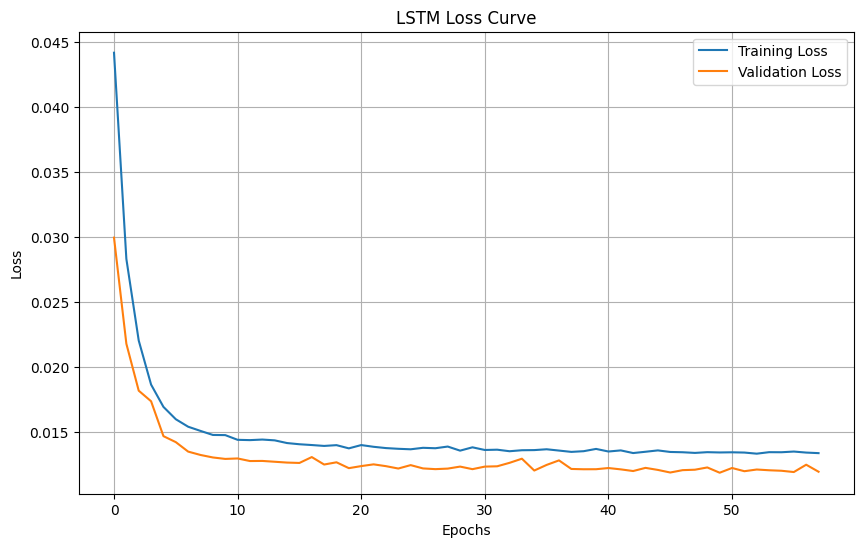

In [372]:
# Assuming `history` is the variable storing the training history from model.fit()
plt.figure(figsize=(10, 6))
plt.plot(model.history.history['loss'], label='Training Loss')
plt.plot(model.history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [373]:
# Create results_df before predictions
results_df = pd.DataFrame({
    'indicator': ind_test,
    'activity_score_normalized': [
        data[data['indicator'] == ind]['activity_score_normalized'].iloc[0]
        if ind in data['indicator'].values else 0.5  # Default to 0.5 if missing
        for ind in ind_test
    ]
})

# Predict on test set
y_pred_prob = model.predict(X_test).flatten()

# Adjust threshold based on activity_score
# Map activity_score_normalized from results_df to ind_test
threshold_map = results_df.set_index('indicator')['activity_score_normalized'].to_dict()

# Calculate thresholds directly without handling missing indicators
thresholds = np.array([
    0.35 + 0.15 * threshold_map[ind]
    for ind in ind_test
])

# Ensure lengths match and apply thresholds
if len(y_pred_prob) != len(thresholds):
    raise ValueError("Mismatch between prediction probabilities and thresholds length.")

y_pred = (y_pred_prob > thresholds).astype(int)

# Group by indicator and calculate stats
from collections import defaultdict

indicator_stats = defaultdict(lambda: {'true': [], 'pred': [], 'prob': []})
for i, ind in enumerate(ind_test):
    indicator_stats[ind]['true'].append(y_test[i])
    indicator_stats[ind]['pred'].append(y_pred[i])
    indicator_stats[ind]['prob'].append(y_pred_prob[i])

# Build summary
summary = []
for ind, vals in indicator_stats.items():
    acc = np.mean(np.array(vals['true']) == np.array(vals['pred']))
    avg_prob = np.mean(vals['prob'])
    date = data[data['indicator'] == ind]['date'].values[0] if ind in data['indicator'].values else np.nan
    seen_value = test_data[test_data['indicator'] == ind]['seen'].values
    seen = seen_value[0] if len(seen_value) > 0 else np.nan  # Handle missing 'seen' values
    summary.append({
        'indicator': ind,
        'accuracy': round(acc, 3),
        'avg_predicted_probability': round(avg_prob, 3),
        'samples': len(vals['true']),
        'seen': seen
    })

# Convert summary to DataFrame
results_df = pd.DataFrame(summary).sort_values(by='avg_predicted_probability', ascending=False)

# Display the top 500 results
results_df.head(500)

385/385 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step


,indicator,accuracy,avg_predicted_probability,samples,seen
222,61.153.184.151,1.000,0.817,28,1
182,162.142.125.247,1.000,0.817,22,1
306,119.200.13.201,1.000,0.817,29,1
221,162.142.125.255,1.000,0.817,28,1
278,162.142.125.242,1.000,0.817,18,1
...,...,...,...,...,...
543,104.248.125.97,1.000,0.136,20,0
261,149.88.27.217,0.958,0.136,24,0
246,39.144.144.37,0.966,0.135,29,0
92,193.32.162.8,1.000,0.135,27,0


In [388]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Classification report
class_report = classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1'])
print("\nClassification Report:")
print(class_report)

# AUC score
auc_score = roc_auc_score(y_test, y_pred_prob)
print(f"\nAUC Score: {auc_score:.4f}")

# Precision, Recall, F1-Score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nPrecision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Confusion Matrix:
[[10012   612]
 [  298  1395]]

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.97      0.94      0.96     10624
     Class 1       0.70      0.82      0.75      1693

    accuracy                           0.93     12317
   macro avg       0.83      0.88      0.86     12317
weighted avg       0.93      0.93      0.93     12317


AUC Score: 0.9397

Precision: 0.6951
Recall: 0.8240
F1-Score: 0.7541


In [374]:
# Extract the indicators from both dataframes
results_indicators = set(results_df['indicator'])
test_data_indicators = set(test_data['indicator'])

# Find matching indicators
matching_indicators = results_indicators.intersection(test_data_indicators)

# Find missing indicators in test_data
missing_in_test_data = results_indicators.difference(test_data_indicators)

# Find missing indicators in sorted_results_df
missing_in_sorted_results = test_data_indicators.difference(results_indicators)

# Display the results
print("Matching Indicators:", matching_indicators)
print("Indicators in results_df but missing in test_data:", missing_in_test_data)
print("Indicators in test_data but missing in results_df:", missing_in_sorted_results)

Matching Indicators: {'45.142.193.196', '94.23.26.20', '45.142.193.183', '149.88.18.238', '194.180.49.218', '146.70.112.126', '165.22.54.16', 'hr-buyerguide.com', '171.25.193.77', '192.81.209.168', '66.132.159.252', 'www.deepseek.com.cdn.cloudflare.net', 'thumb-p1.xhcdn.com', '45.142.193.66', '207.244.89.161', '193.32.162.8', '198.44.136.56', '146.190.169.165', '165.22.84.147', '23.106.56.38', '45.11.3.235', '37.44.238.88', '46.246.8.119', '193.32.162.83', '45.134.140.144', 'cdn.deepseek.com', '23.26.221.3', '37.19.210.21', '111.67.197.113', '184.185.2.12', '176.123.2.25', '185.213.155.241', '195.181.160.173', 'www.sthda.com', '162.241.248.14', '185.224.0.235', '138.199.21.209', '185.156.46.141', 'platform.deepseek.com', '103.149.249.226', '171.25.193.20', 'static-ca-cdn.eporner.com', '107.189.30.69', '149.88.17.134', 'complete-physio.co.uk', '79.124.49.226', '91.196.152.66', 'pub.marq.com', 'beatthewonderlic.com', '149.88.27.231', 'hmh.org', '37.148.204.40', '95.173.217.70', '172.240.

In [375]:

# Filter the matching indicators from results_df
matching_indicators_data = results_df[results_df['indicator'].isin(data['indicator'])]

# Get the list of indicators from matching_indicators_data
matching_indicators = matching_indicators_data['indicator'].unique()

# Filter the last 90 days of data for these indicators where seen = 1
ninety_days_ago = datetime.now() - timedelta(days=90)
seen_in_last_90_days = data[
    (data['indicator'].isin(matching_indicators)) & 
    (data['seen'] == 1) & 
    (data['date'] >= ninety_days_ago)
]

# Get the list of indicators that have been seen
seen_indicators = seen_in_last_90_days['indicator'].unique()

# Find indicators that have not been seen in the last 90 days
not_seen_indicators = set(matching_indicators) - set(seen_indicators)

# Display the indicators not seen in the last 90 days
if not_seen_indicators:
    print("The following indicators have NOT been seen in the last 90 days:")
    print(not_seen_indicators)
else:
    print("All matching indicators have been seen in the last 90 days.")

# Exclude not_seen_indicators from the display list
display_indicators = set(matching_indicators) - not_seen_indicators

# Display the results
matching_indicators_data[matching_indicators_data['indicator'].isin(display_indicators)][['indicator', 'avg_predicted_probability']]

The following indicators have NOT been seen in the last 90 days:
{'89.250.72.16', '211.143.253.166', '223.233.80.122', '75.127.12.162', '156.146.63.163', '149.88.17.134', '185.253.162.21', '134.122.109.15', '84.17.45.157', '79.124.58.194', '104.248.125.97', 'ccic-cths@cms.hhs.gov', '149.88.27.200', 'my.rtmark.net', '201.183.247.58', '41.79.199.36', '84.17.45.159', '141.98.252.143', '164.92.231.207', '107.173.179.59', '185.208.159.43', '84.207.244.250', '45.134.140.171', '146.70.204.173', '149.88.27.209', 'neodove.com', '45.86.200.81', '172.98.33.195', '37.19.200.155', '104.248.27.51', '149.88.27.196', '156.146.63.176', '167.71.10.37', '46.8.198.196', 'www.filemail.com', '39.144.144.52', '64.64.112.158', '104.152.52.200', '165.22.194.104', '149.88.27.198', '87.236.176.51', '37.139.145.57', '23.26.221.29', '185.213.155.241', '165.227.155.36', '139.59.138.57', '197.156.93.93', '62.182.98.170', '169.150.203.22', '198.98.54.209'}


,indicator,avg_predicted_probability
222,61.153.184.151,0.817
182,162.142.125.247,0.817
306,119.200.13.201,0.817
221,162.142.125.255,0.817
278,162.142.125.242,0.817
...,...,...
511,64.64.112.131,0.122
84,46.246.8.77,0.122
540,149.88.27.213,0.121
88,146.70.204.183,0.119


In [376]:
# Add a column to indicate whether the prediction was "Right" or "Wrong"
matching_indicators_data.loc[:, 'prediction_status'] = matching_indicators_data.apply(
    lambda row: 'Right' if (row['avg_predicted_probability'] >= 0.5 and row['seen'] == 1) or
                              (row['avg_predicted_probability'] < 0.5 and row['seen'] == 0)
                else 'Wrong',
    axis=1
)

# Identify false negatives: indicators in matching_indicators_data but below the threshold
false_negatives = results_df[
    (results_df['indicator'].isin(matching_indicators_data['indicator'])) & 
    (results_df['avg_predicted_probability'] < 0.5) &  # Below the threshold for being seen
    (results_df['seen'] == 1) &  # Actual value is seen
    (~results_df['indicator'].isin(not_seen_indicators))
].copy()

if not false_negatives.empty:
    false_negatives.loc[:, 'prediction_status'] = 'False Negative'

# Identify false positives: indicators not in matching_indicators_data but meet the threshold
false_positives = results_df[
    (results_df['avg_predicted_probability'] >= 0.5) &  # Above the threshold for being seen
    (results_df['seen'] == 0) &  # Actual value is not seen
    (~results_df['indicator'].isin(not_seen_indicators))
].copy()

if not false_positives.empty:
    false_positives.loc[:, 'prediction_status'] = 'False Positive'

# Combine all results
combined_results = pd.concat([matching_indicators_data, false_negatives, false_positives])

# Resolve duplicate indicators by prioritizing "False Negative" and "False Positive" over "Wrong"
final_results = (
    combined_results.sort_values(by='prediction_status', key=lambda col: col.map({'False Negative': 1, 'False Positive': 2, 'Wrong': 3, 'Right': 4}))
    .drop_duplicates(subset='indicator', keep='first')
)

# Display the final results
final_results[['indicator', 'avg_predicted_probability', 'seen', 'prediction_status']]

,indicator,avg_predicted_probability,seen,prediction_status
486,45.142.193.183,0.319,1,False Negative
452,104.192.3.74,0.171,1,False Negative
451,169.150.223.208,0.194,1,False Negative
101,45.84.107.128,0.201,1,False Negative
281,194.180.49.217,0.205,1,False Negative
...,...,...,...,...
274,23.205.105.180,0.657,1,Right
221,162.142.125.255,0.817,1,Right
306,119.200.13.201,0.817,1,Right
182,162.142.125.247,0.817,1,Right


In [377]:
# Calculate total predictions and total right predictions from final_results
total_predictions_final = len(final_results)
total_right_predictions_final = len(final_results[final_results['prediction_status'] == 'Right'])

# Calculate the ratio
right_predictions_ratio_final = total_right_predictions_final / total_predictions_final

# Print the ratio in '199/205' format
print(f"Ratio of right predictions to total predictions (final results): {total_right_predictions_final}/{total_predictions_final}")

# Calculate the accuracy of the ratio
accuracy_final = (total_right_predictions_final / total_predictions_final) * 100

# Print the accuracy
print(f"Accuracy (final results): {accuracy_final:.2f}%")

Ratio of right predictions to total predictions (final results): 498/565
Accuracy (final results): 88.14%


In [378]:
# Extract rows where prediction_status is either "False Negative" or "False Positive"
false_negatives_and_positives = final_results[
    final_results['prediction_status'].isin(['False Negative', 'False Positive'])
].copy()

# Display the extracted rows
false_negatives_and_positives

,indicator,accuracy,avg_predicted_probability,samples,seen,prediction_status
486,45.142.193.183,1.000,0.319,25,1,False Negative
452,104.192.3.74,1.000,0.171,21,1,False Negative
451,169.150.223.208,1.000,0.194,18,1,False Negative
101,45.84.107.128,1.000,0.201,18,1,False Negative
281,194.180.49.217,1.000,0.205,21,1,False Negative
...,...,...,...,...,...,...
398,i.postimg.cc,0.783,0.583,23,0,False Positive
412,180.76.51.64,1.000,0.634,17,0,False Positive
361,203.239.31.150,0.864,0.555,22,0,False Positive
85,192.42.116.191,0.619,0.537,21,0,False Positive


In [379]:
correct_seen_predictions = ((final_results['seen'] == 1) & (final_results['prediction_status'] == 'Right'))
correct_seen_predictions

486    False
452    False
451    False
101    False
281    False
       ...  
274     True
221     True
306     True
182     True
222     True
Length: 565, dtype: bool

In [380]:
((final_results['seen'] == 1) & (final_results['prediction_status'] == 'Right')).sum()


np.int64(18)

In [381]:
# Calculate the number of correct "seen" predictions
correct_seen_predictions = ((final_results['seen'] == 1) & (final_results['prediction_status'] == 'Right')).sum()

# Calculate the total actual "seen" values
total_actual_seen = (final_results['seen'] == 1).sum()

Ratio = correct_seen_predictions / total_actual_seen * 100
# Print the results
print(f"Number of correct 'seen' predictions: {correct_seen_predictions}")
print(f"Total actual 'seen': {total_actual_seen}")
print(f"Ratio : {Ratio:.2f}")

Number of correct 'seen' predictions: 18
Total actual 'seen': 65
Ratio : 27.69


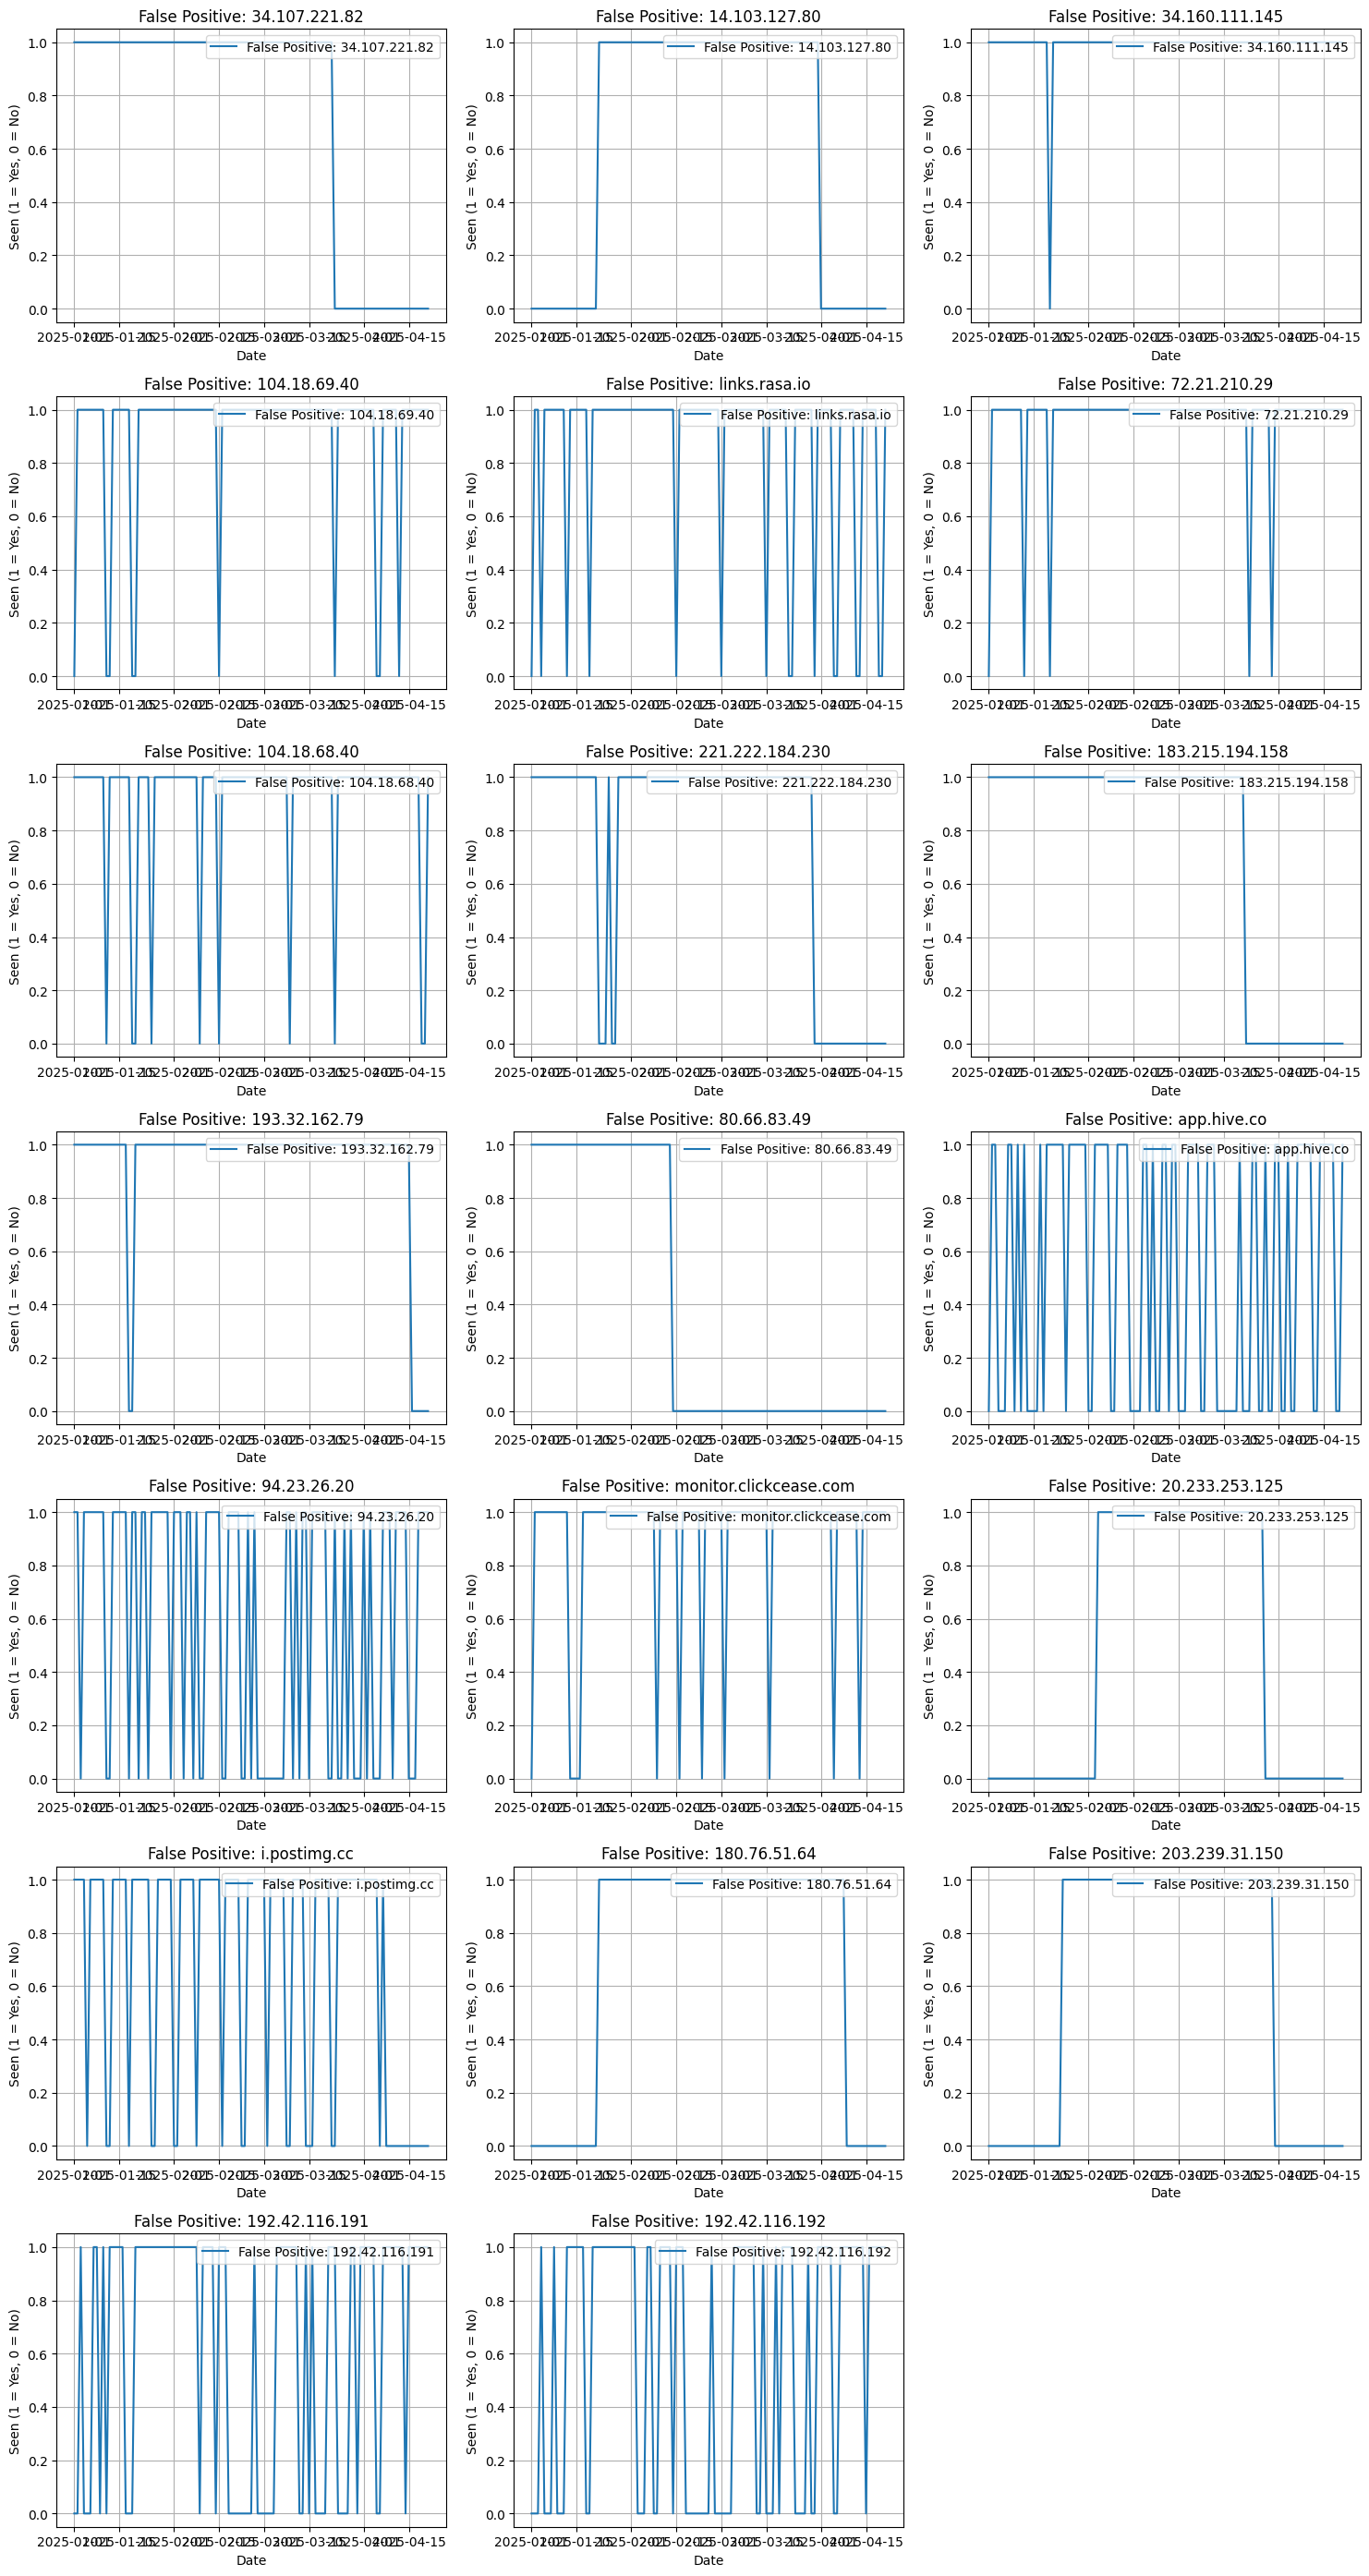

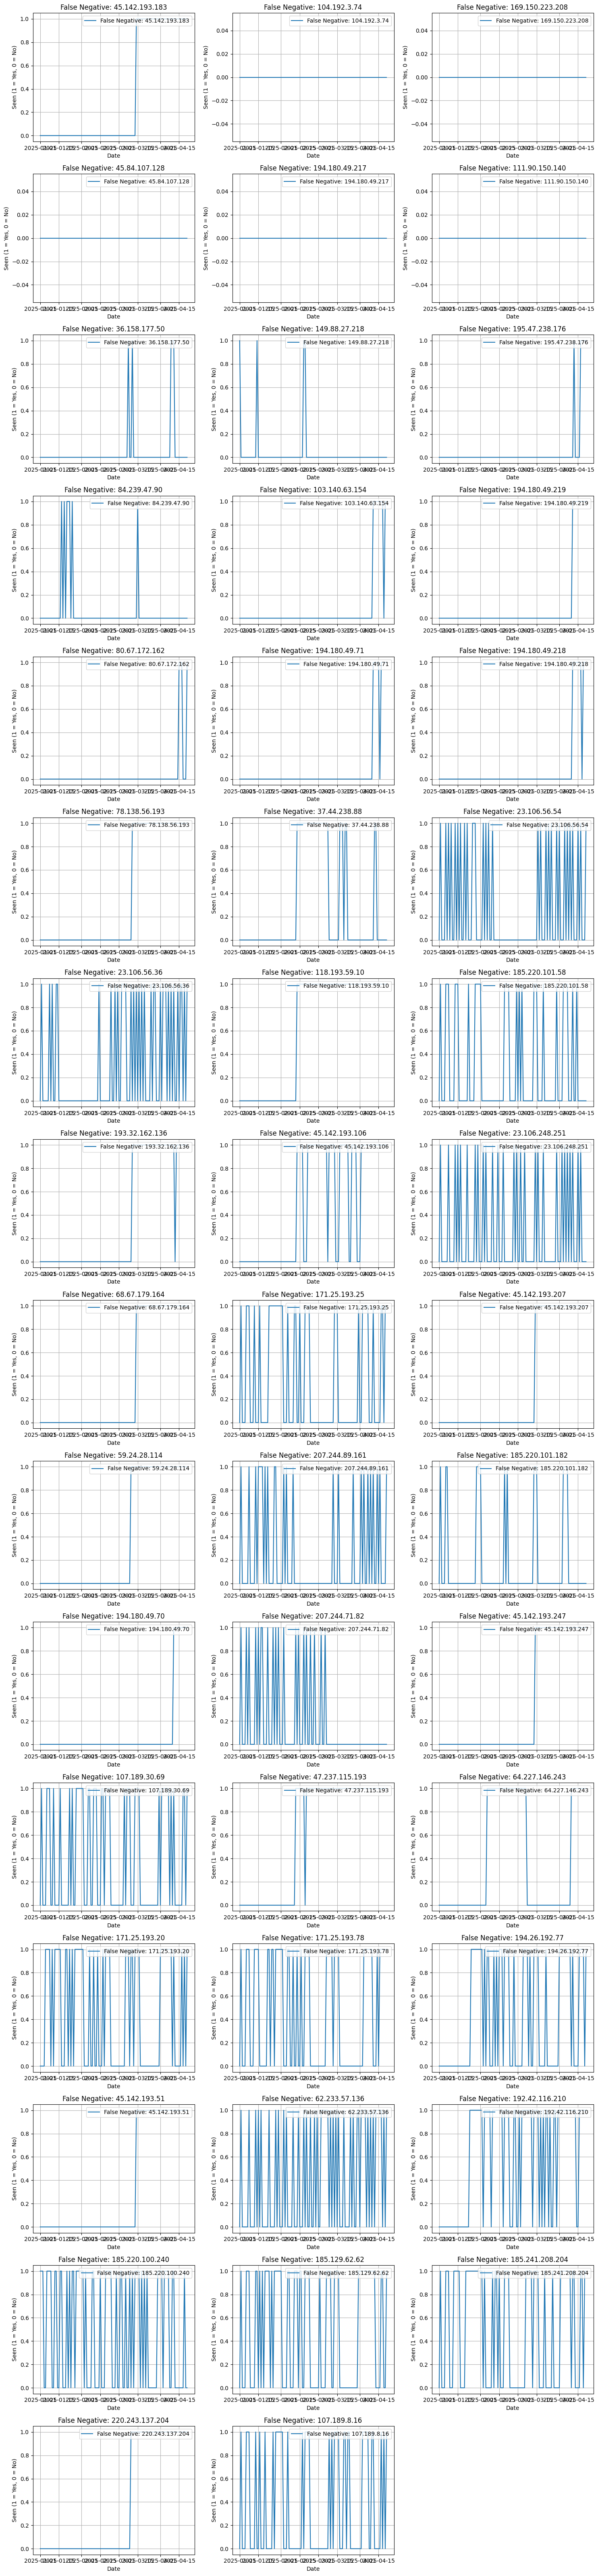

In [382]:
import matplotlib.pyplot as plt
import math

# Separate false positives and false negatives
false_positives = false_negatives_and_positives[
    false_negatives_and_positives['prediction_status'] == 'False Positive'
]

false_negatives = false_negatives_and_positives[
    false_negatives_and_positives['prediction_status'] == 'False Negative'
]

# Merge false positives and false negatives with modelData to get historical activity
false_positive_activity = modelData[modelData['indicator'].isin(false_positives['indicator'])]
false_negative_activity = modelData[modelData['indicator'].isin(false_negatives['indicator'])]

# Function to plot indicators in a grid
def plot_indicators_in_grid(activity_data, indicators, title_prefix):
    num_indicators = len(indicators)
    cols = 3  # Number of columns in the grid
    rows = math.ceil(num_indicators / cols)  # Calculate rows needed

    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
    axes = axes.flatten()  # Flatten the axes array for easy iteration

    for i, indicator in enumerate(indicators):
        ax = axes[i]
        indicator_data = activity_data[activity_data['indicator'] == indicator]
        ax.plot(indicator_data['date'], indicator_data['seen'], label=f'{title_prefix}: {indicator}')
        ax.set_title(f'{title_prefix}: {indicator}')
        ax.set_xlabel('Date')
        ax.set_ylabel('Seen (1 = Yes, 0 = No)')
        ax.legend(loc='upper right')
        ax.grid(True)

    # Hide any unused subplots
    for i in range(len(indicators), len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

# Plot false positives in a grid
plot_indicators_in_grid(false_positive_activity, false_positives['indicator'].unique(), 'False Positive')

# Plot false negatives in a grid
plot_indicators_in_grid(false_negative_activity, false_negatives['indicator'].unique(), 'False Negative')

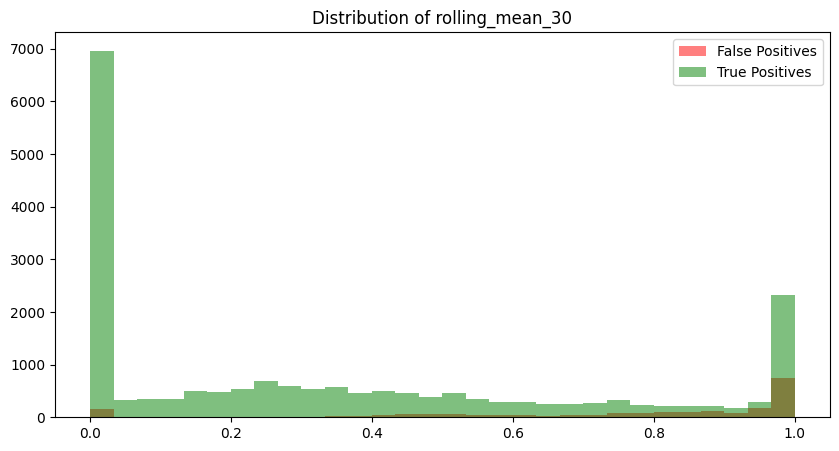

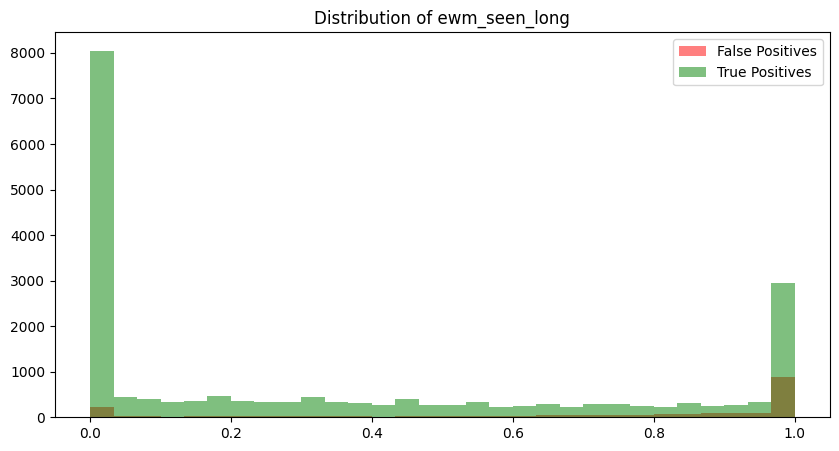

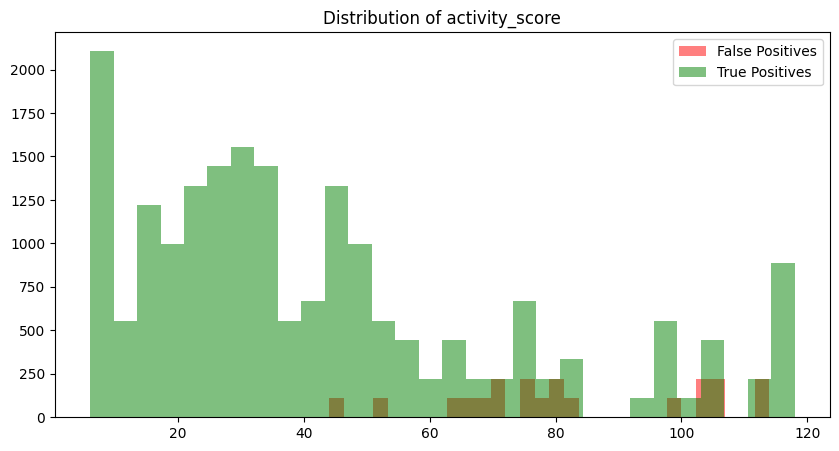

In [383]:
false_positive_data = modelData[modelData['indicator'].isin(false_positives['indicator'])]
# Get the indices of true positives
true_positive_indices = np.where((y_pred == 1) & (y_test == 1))[0]

# Filter modelData for true positives using the corresponding indicators
true_positive_indicators = ind_test[true_positive_indices]
true_positive_data = modelData[modelData['indicator'].isin(true_positive_indicators)]

# Compare feature distributions
for feature in ['rolling_mean_30', 'ewm_seen_long', 'activity_score']:
    plt.figure(figsize=(10, 5))
    plt.hist(false_positive_data[feature], bins=30, alpha=0.5, label='False Positives', color='red')
    plt.hist(true_positive_data[feature], bins=30, alpha=0.5, label='True Positives', color='green')
    plt.title(f'Distribution of {feature}')
    plt.legend()
    plt.show()

In [384]:
modelData[modelData['indicator'] == '68.67.179.164']

,date,indicator,dayofweek,is_weekend,seen,days_since_last_seen,ewm_seen,seen_count_last_3,rolling_mean_7,rolling_mean_14,...,total_seen_last_14,total_seen_last_7,total_seen_last_3,total_days_not_seen_last_30,total_days_not_seen_last_14,total_days_not_seen_last_7,activity_score,activity_score_normalized,activity_tier,smoothed_days_since_last_seen
47064,2025-01-01,68.67.179.164,2,False,0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,30.0,14.0,7.0,46,0.384615,2,24.002859
47065,2025-01-02,68.67.179.164,3,False,0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,30.0,14.0,7.0,46,0.384615,2,19.202287
47066,2025-01-03,68.67.179.164,4,False,0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,30.0,14.0,7.0,46,0.384615,2,15.361830
47067,2025-01-04,68.67.179.164,5,True,0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,30.0,14.0,7.0,46,0.384615,2,12.289464
47068,2025-01-05,68.67.179.164,6,True,0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,30.0,14.0,7.0,46,0.384615,2,9.831571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47170,2025-04-17,68.67.179.164,3,False,1,1,1.0,3.0,1.0,1.0,...,14.0,7.0,3.0,0.0,0.0,0.0,46,0.384615,2,0.999493
47171,2025-04-18,68.67.179.164,4,False,1,1,1.0,3.0,1.0,1.0,...,14.0,7.0,3.0,0.0,0.0,0.0,46,0.384615,2,0.999594
47172,2025-04-19,68.67.179.164,5,True,1,1,1.0,3.0,1.0,1.0,...,14.0,7.0,3.0,0.0,0.0,0.0,46,0.384615,2,0.999675
47173,2025-04-20,68.67.179.164,6,True,1,1,1.0,3.0,1.0,1.0,...,14.0,7.0,3.0,0.0,0.0,0.0,46,0.384615,2,0.999740


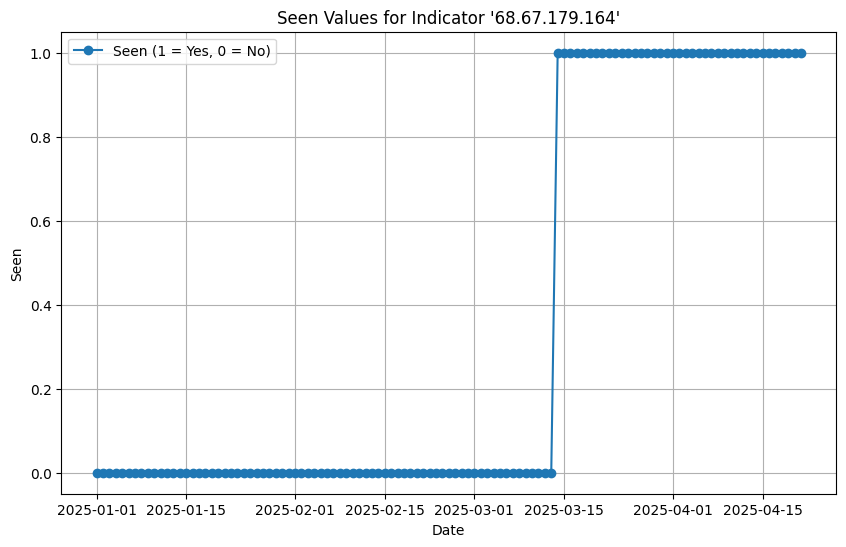

In [385]:
# Filter data for the specified indicator
indicator_data = modelData[modelData['indicator'] == '68.67.179.164']

# Plot the 'seen' values over time
plt.figure(figsize=(10, 6))
plt.plot(indicator_data['date'], indicator_data['seen'], marker='o', label='Seen (1 = Yes, 0 = No)')
plt.title("Seen Values for Indicator '68.67.179.164'")
plt.xlabel("Date")
plt.ylabel("Seen")
plt.legend()
plt.grid(True)
plt.show()

In [386]:
days_since_last_seen = modelData['days_since_last_seen']

days_since_last_seen = test_data.groupby('indicator').agg({
    'days_since_last_seen': ['mean', 'max']
}).reset_index()

# Rename columns for clarity
days_since_last_seen.columns = ['indicator', 'mean_days_since_last_seen', 'max_days_since_last_seen']

days_since_last_seen

,indicator,mean_days_since_last_seen,max_days_since_last_seen
0,102.165.16.161,22.0,22
1,102.68.39.251,35.0,35
2,103.140.63.154,1.0,1
3,103.149.249.226,33.0,33
4,103.216.220.19,4.0,4
...,...,...,...
560,www.powerlineblog.com,9.0,9
561,www.sthda.com,5.0,5
562,www.thetruthaboutguns.com,6.0,6
563,www.totem.tech,27.0,27


Top Features:
                                Feature  Importance
15                     lag_2_ewm_seen_1    0.132176
11                lag_2_ewm_seen_long_1    0.124636
13                lag_2_ewm_seen_long_2    0.100154
14                     lag_1_ewm_seen_1    0.068769
5   lag_2_smoothed_days_since_last_seen    0.068690
4   lag_1_smoothed_days_since_last_seen    0.067097
10                lag_1_ewm_seen_long_1    0.063768
16                     lag_1_ewm_seen_2    0.044775
17                     lag_2_ewm_seen_2    0.042726
19              lag_2_rolling_mean_30_1    0.040008


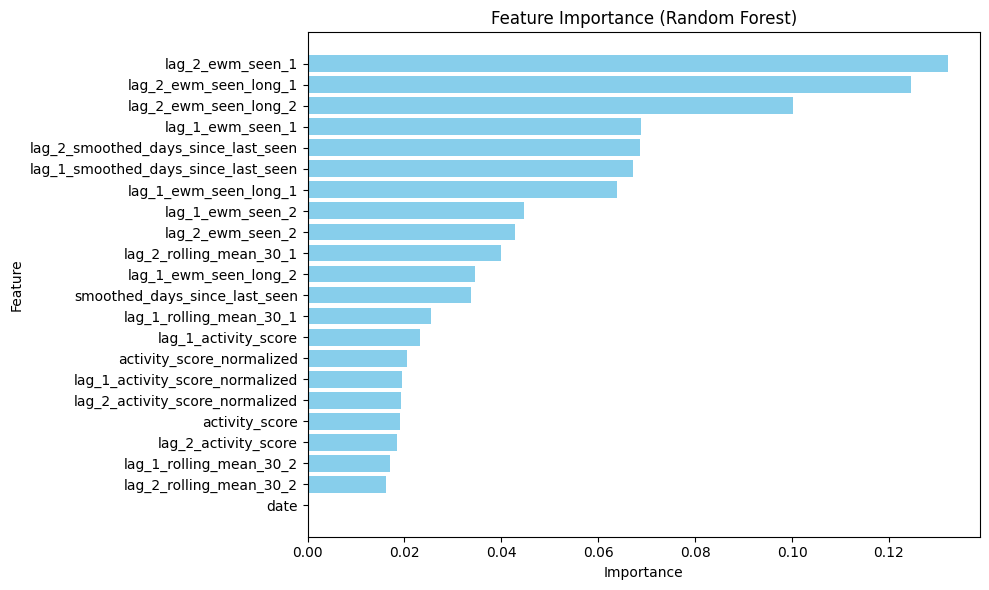

In [387]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Get feature importances
feature_importances = rf_model.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Display the top features
print("Top Features:")
print(feature_importance_df.head(10))

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance (Random Forest)')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature at the top
plt.tight_layout()
plt.show()